# Project: Safety in Aviation Industry — U.S. Commercial Aviation (2003–2022)

## Business Problem

Aviation accidents have significant human and economic consequences. Understanding whether commercial air travel is becoming safer over time — and by how much — is a question of direct relevance to regulators, airlines, and the traveling public. This project uses publicly available accident and traffic data to quantify the safety trend in U.S. commercial aviation over the past two decades.

**Author:** Matheus Hagemann  
**Tools:** Python · Pandas · Matplotlib
**Data Sources:**  
- [Airplane Crashes & Fatalities (Kaggle)](https://www.kaggle.com/datasets/nayansubedi1/airplane-crashes-and-fatalities-upto-2023/data)  
- [U.S. Airline Traffic Data (Kaggle)](https://www.kaggle.com/datasets/yyxian/u-s-airline-traffic-data)

---

## Research Questions
1. Is commercial aviation in the U.S. safer today than it was two decades ago?
2. What does the accident rate trend suggest about future safety?

## Scope
This notebook analyzes **U.S. commercial aviation accidents** from **2003 to 2022**, combining accident records with annual flight volume data to compute a normalized accident rate (accidents per domestic flight). Military, private, and non-commercial operations are excluded.

---
# 1. Libraries & Data Loading

- `pandas` and `numpy` for data loading and manipulation.
- `matplotlib` and `seaborn` for visualization.
- `mticker` for custom axis formatting on the accident rate chart.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline

# Display settings
pd.set_option('display.float_format', '{:,.4f}'.format)
pd.set_option('display.max_columns', 20)

print("Libraries loaded.")

Libraries loaded.


In [2]:
import os
is_kaggle = 'KAGGLE_KERNEL_RUN_TYPE' in os.environ

In [3]:
if is_kaggle:
    ACCIDENTS_PATH = "/kaggle/input/datasets/nayansubedi1/airplane-crashes-and-fatalities-upto-2023/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv"
else:
    !pip install -q kaggle
    os.environ['KAGGLE_CONFIG_DIR'] = "/content/"
    !kaggle datasets download -d <your-slug>
    !unzip -o <zip>.zip
    ACCIDENTS_PATH = "Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv"

df_original = pd.read_csv(ACCIDENTS_PATH, on_bad_lines='skip', encoding='latin1')
df = df_original.copy()
print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].iloc[0]} → {df['Date'].iloc[-1]}")

Shape: (4998, 17)
Date range: 9/17/1908 → 11/1/2023


- Check dataset dimensions and missing values per column to plan the cleaning steps.

In [4]:
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(f"\nMissing values per column:")
print(df.isnull().sum())

Rows: 4,998 | Columns: 17

Missing values per column:
Date                        0
Time                     1512
Location                    4
Operator                   10
Flight #                 3669
Route                     777
AC Type                    15
Registration              274
cn/ln                     668
Aboard                     18
Aboard Passangers         229
Aboard Crew               226
Fatalities                  8
Fatalities Passangers     242
Fatalities Crew           241
Ground                     42
Summary                    64
dtype: int64


---
- Explore the first and last records to confirm the dataset loaded correctly and understand its raw structure.

In [5]:
df.head()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0000,0.0000,5.0000,5.0000,0.0000,5.0000,0.0000,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0000,NaN,NaN,14.0000,NaN,NaN,0.0000,The airship flew into a thunderstorm and encou...


In [6]:
df.tail()

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
4993,11/21/2022,10:15,"Medellín, Colombia",AeroPaca SAS,NaN,Medellín - Pizarro,Piper PA-31-350 Navajo Chieftain,HK-5121,31-7652004,8.0000,6.0000,2.0000,8.0000,6.0000,2.0000,0.0000,The plane was chartered to carry a team of six...
4994,1/15/2023,10:50,"Pokhara, Nepal",Yeti Airlines,YT691,Kathmandu - Pokhara,ATR 72-500-72-212-A,9NANC,754,72.0000,68.0000,4.0000,72.0000,68.0000,4.0000,0.0000,"Before approach, the pilot requested a change ..."
4995,9/16/2023,NaN,"Barcelos, Brazil",Manaus Aerotaxi,NaN,NaN,Embraer EMB-110P1 Bandeirante,PT-SOG,110490,14.0000,12.0000,2.0000,14.0000,12.0000,2.0000,0.0000,The air taxi crashed in heavy rain while attem...
4996,10/29/2023,6:30,"Rio Branco, Brazil",ART Taxi Aero,NaN,Rio Branco - Envira,Cessna 208B Grand Caravan,PT-MEE,208B0344,12.0000,10.0000,2.0000,12.0000,10.0000,2.0000,0.0000,The air taxi crashed into a heavy wooded area ...
4997,11/1/2023,14:15,"Morelos, Mexico",Jet Rescue Air Ambulance,NaN,Toluca - Cuernavaca Airport,\tLearjet 35A,XA-IRE,35A-354,4.0000,2.0000,2.0000,4.0000,2.0000,2.0000,0.0000,"A business jet operating as an air ambulance, ..."


### => Conclusions:
- The dataset spans from **1908 to 2023**, covering 115 years of aviation history.
- Early records (1908–1920s) are sparse and involve experimental or military aircraft — far outside the scope of modern commercial aviation.
- Recent records (2022–2023) confirm the dataset is current, with recognizable commercial operators such as Yeti Airlines and AeroPaca.
- The `Date` column requires parsing — it is stored as `M/D/YYYY` strings, not integers.
- Several columns (`Time`, `Flight #`, `Registration`) are heavily null and will be dropped in the next step.

### Dataset Summary

| Field | Value |
|-------|-------|
| Records | 4,998 accidents |
| Period | 1908–2023 |
| Scope | Global — military, private, and commercial operations |
| Key numeric columns | `Aboard`, `Fatalities` |
| Notable missingness | `Time` (1,512 nulls), `Flight #` (3,669 nulls) — both to be dropped |

---
# 2. Data Cleaning

-  The `Date` column is stored as `M/D/YYYY` strings. Only the year is needed for annual aggregation, so it is extracted and converted to integer.

In [7]:
# Extract year from 'M/D/YYYY' date strings
df['Date'] = df['Date'].str.split('/').str[-1].astype(int)

print(f"Year range: {df['Date'].min()} – {df['Date'].max()}")
df['Date'].value_counts().sort_index().tail(10)

Year range: 1908 – 2023


Date
2014    23
2015    18
2016    23
2017    15
2018    16
2019    13
2020     8
2021     9
2022     6
2023     4
Name: count, dtype: int64

### => Conclusions:
- Year extraction successful. The dataset spans **1908 to 2023** (116 years).
- The most recent years (2020–2023) show declining accident counts — partly reflecting real safety improvement, and partly the COVID-19 traffic collapse in 2020.

---
- Drop Redundant and Out-of-Scope Columns. The following columns are removed before analysis:

  - `Time`, `Flight #`, `Registration`, `cn/ln` — operational identifiers not relevant to this analysis.
  - `Aboard Passangers`, `Aboard Crew` — redundant with the `Aboard` total column.
  - `Fatalities Passangers`, `Fatalities Crew` — redundant with the `Fatalities` total column.
  - `Ground` — casualties on the ground are outside the scope of in-flight safety analysis.

In [8]:
# Drop columns
df = df.drop(columns=[
    'Time', 'Flight #', 'Registration', 'cn/ln',
    'Aboard Passangers', 'Aboard Crew',
    'Fatalities Passangers', 'Fatalities Crew',
    'Ground'
], errors='ignore')

df = df.drop_duplicates()

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Shape after cleaning: (4998, 8)
Remaining columns: ['Date', 'Location', 'Operator', 'Route', 'AC Type', 'Aboard', 'Fatalities', 'Summary']


---
- Statistical summary of the cleaned dataset. Key things to verify: year range, average fatalities per accident, and whether any core numeric columns have unexpected ranges.

In [9]:
df.describe(include='all')

,Date,Location,Operator,Route,AC Type,Aboard,Fatalities,Summary
count,"4,998.0000",4994,4988,4221,4983,"4,980.0000","4,990.0000",4934
unique,NaN,4122,2264,3825,2463,NaN,NaN,4839
top,NaN,"Moscow, Russia",Aeroflot,Training,Douglas DC-3,NaN,NaN,Crashed under unknown circumstances.
freq,NaN,17,255,93,333,NaN,NaN,9
mean,"1,970.9908",NaN,NaN,NaN,NaN,31.1960,22.3735,NaN
std,24.7965,NaN,NaN,NaN,NaN,45.5348,35.0617,NaN
min,"1,908.0000",NaN,NaN,NaN,NaN,0.0000,0.0000,NaN
25%,"1,951.0000",NaN,NaN,NaN,NaN,7.0000,4.0000,NaN
50%,"1,970.0000",NaN,NaN,NaN,NaN,16.0000,11.0000,NaN
75%,"1,992.0000",NaN,NaN,NaN,NaN,35.0000,25.0000,NaN


### => Conclusions:
- **Date:** Mean year is ~1971, median is 1970 — the dataset is historically skewed toward the mid-20th century.
- **Aboard:** Average of ~31 people per accident, max of 644 — consistent with large commercial jet disasters.
- **Fatalities:** Average of ~22 per accident. The gap between `Aboard` and `Fatalities` means survivability is non-zero even in recorded accidents.
- **Most frequent operator:** Aeroflot (255 accidents) — reflecting its large fleet and historically high accident rate during the Soviet era.
- **Most frequent aircraft:** Douglas DC-3 (333 accidents) — the dominant commercial aircraft of the mid-20th century.

---
- Final null check on the key columns that will be used in downstream filtering and analysis.

In [10]:
print(f"Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNull counts:")
print(df[['Aboard', 'Fatalities', 'Operator', 'Location']].isnull().sum())

Final shape: 4,998 rows × 8 columns

Null counts:
Aboard        18
Fatalities     8
Operator      10
Location       4
dtype: int64


### => Conclusions:
- `Aboard` and `Fatalities` have small null counts (18 and 8 respectively) — acceptable for a dataset of ~5,000 records. These nulls are concentrated in early historical records and will not materially affect the 2003–2022 analysis.
- `Operator` has 10 nulls — these rows will be dropped during the U.S. filter step.
- `Location` has 4 nulls — also dropped downstream.
- The cleaned dataset is ready for scope filtering.

# 3. Traffic Dataset & Scope Decision

- The accidents dataset covers 1908–2023 globally, but records **only accidents** — not total flights. Without total flight volume as a denominator, raw accident counts are misleading: a year with 20 accidents and 1 million flights is far safer than a year with 10 accidents and 50,000 flights.

- To compute a meaningful **accident rate**, annual flight counts are needed as the denominator.

  - **Decision:** Narrow the analysis to **U.S. commercial aviation, 2003–2022**, using the U.S. Airline Traffic dataset (monthly data, Jan 2003–Sep 2023) as the flight volume source. This period provides consistent, reliable traffic data for domestic commercial operations.

  - **Source:** [U.S. Airline Traffic Data — Kaggle](https://www.kaggle.com/datasets/yyxian/u-s-airline-traffic-data)

In [11]:
if is_kaggle:
    TRAFFIC_PATH = "/kaggle/input/datasets/yyxian/u-s-airline-traffic-data/air traffic.csv"
else:
    TRAFFIC_PATH = "air traffic.csv"

traffic = pd.read_csv(TRAFFIC_PATH)
print(f"Shape: {traffic.shape}")
print(f"Columns: {list(traffic.columns)}")

Shape: (249, 17)
Columns: ['Year', 'Month', 'Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt', 'Flt', 'Dom_RPM', 'Int_RPM', 'RPM', 'Dom_ASM', 'Int_ASM', 'ASM', 'Dom_LF', 'Int_LF', 'LF']


In [12]:
print(f"Period: {traffic['Year'].min()} – {traffic['Year'].max()}")
print(f"Monthly rows: {len(traffic)}")
traffic[['Year','Month']].describe().astype(int)

Period: 2003 – 2023
Monthly rows: 249


,Year,Month
count,249,249
mean,2012,6
std,6,3
min,2003,1
25%,2008,3
50%,2013,6
75%,2018,9
max,2023,12


### 3.1 Clean & Aggregate Traffic Data

- Columns not needed for this analysis are dropped. Numeric fields stored as comma-formatted strings are converted to integers. Monthly records are aggregated to annual totals. The incomplete 2023 record (data only through September) is excluded to avoid understating that year's traffic volume.




In [13]:
# Load, clean, and aggregate U.S. airline traffic data into annual totals

traffic = pd.read_csv(TRAFFIC_PATH)

# Columns to keep
keep_cols = ['Year', 'Dom_Pax', 'Int_Pax', 'Pax', 'Dom_Flt', 'Int_Flt', 'Flt']
traffic = traffic[keep_cols]

# Rename for readability
traffic = traffic.rename(columns={
    'Dom_Pax': 'Domestic Passengers',
    'Int_Pax': 'International Passengers',
    'Pax':     'Total Passengers',
    'Dom_Flt': 'Domestic Flights',
    'Int_Flt': 'International Flights',
    'Flt':     'Total Flights'
})

# Remove comma formatting and convert to int
numeric_cols = [c for c in traffic.columns if c != 'Year']
for col in numeric_cols:
    traffic[col] = traffic[col].astype(str).str.replace(',', '', regex=False).astype(int)

# Aggregate monthly → annual
traffic = traffic.groupby('Year', as_index=False).sum()

# Drop 2023: incomplete data (only Jan–Sep)
traffic = traffic[traffic['Year'] < 2023].reset_index(drop=True)

print(f"Traffic dataset: {traffic.shape[0]} annual rows ({traffic['Year'].min()}–{traffic['Year'].max()})")
traffic.head(3)

Traffic dataset: 20 annual rows (2003–2022)


,Year,Domestic Passengers,International Passengers,Total Passengers,Domestic Flights,International Flights,Total Flights
0,2003,583293762,60941211,644234973,9453415,682748,10136163
1,2004,629768486,70462241,700230727,9962389,737274,10699663
2,2005,657261487,77843181,735104668,10033140,792741,10825881


### => Conclusions:
- Traffic dataset cleaned and aggregated: **20 annual rows** covering 2003–2022.
- Domestic flights peaked at approximately **10M per year in 2004–2005**, then declined through the 2008 financial crisis, partially recovered into the mid-2010s, and collapsed in **2020** due to COVID-19 (−42% vs. 2019) before recovering through 2022.
- This volume data will serve as the denominator for the accident rate calculation.

# 4. Filter Accidents: U.S. Commercial Operations (2003–2022)

- Three sequential filters narrow the global accident dataset to the scope of this analysis:

  1. **Geography** — Keep only accidents where `Location` contains a U.S. state name.
  2. **Operator type** — Remove military, private, helicopter, government, and non-commercial operators.
  3. **Period** — Keep only years 2003–2022, matching the traffic dataset.

In [14]:
us_states = [
    "Alabama", "Alaska", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "Florida", "Georgia", "Hawaii", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts", "Michigan",
    "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska", "Nevada", "New Hampshire",
    "New Jersey", "New Mexico", "New York", "North Carolina", "North Dakota", "Ohio",
    "Oklahoma", "Oregon", "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington", "West Virginia",
    "Wisconsin", "Wyoming",
    # Common abbreviations also present in the dataset
    ", Virginia", ", Texas", ", California", ", New York"
]

df['is_US'] = df['Location'].fillna('').astype(str).apply(
    lambda x: any(state in x for state in us_states)
)

df = df[df['is_US']].copy()
df = df[df['Operator'].notna()].copy()

print(f"After U.S. filter: {df.shape[0]:,} accidents")


After U.S. filter: 1,030 accidents


### => Conclusions:
- **1,030 accidents** remain after the U.S. geography filter, down from 4,998 globally (~21% of all records).
- The filter uses U.S. state name matching on the `Location` field. Accidents described as "Near [city], [State]" or "[City], [State]" are correctly captured. Accidents in U.S. territories (Puerto Rico, Guam) may be missed.

### 4.1 Remove Non-Commercial Operators
- Operators are classified by keyword matching on the `Operator` field. Records containing any of the following terms (case-insensitive) are excluded: `military`, `private`, `helicopter`, `government`, `non-commercial`.

In [15]:
non_commercial_keywords = ['military', 'private', 'helicopter', 'government', 'non-commercial']

df['is_commercial'] = ~df['Operator'].astype(str).str.lower().apply(
    lambda x: any(kw in x for kw in non_commercial_keywords)
)

before = len(df)
df = df[df['is_commercial']].copy()
after = len(df)

print(f"Removed {before - after} non-commercial records.")
print(f"Remaining: {after} accidents")

Removed 220 non-commercial records.
Remaining: 810 accidents


### => Conclusions:
- **220 non-commercial records removed** (military, private, helicopter, government). **810 accidents remain.**
- The filtering reduces the dataset by ~21%, confirming that a significant share of U.S. accidents involve non-commercial operations outside the scope of this analysis.
- **Limitation:** The non-commercial filter uses keyword matching on the `Operator` field. Some edge cases may survive — air ambulance services, balloon operators, and charter flying clubs are examples. This is an acceptable approximation for an exploratory analysis. A production-grade implementation would use a curated operator classification table.

# 5. Accident Rate Computation

- Accidents are counted per year, then merged with the annual traffic data. The accident rate is defined as:

$$\text{Accident Rate (\%)} = \frac{\text{Accidents in year}}{\text{Domestic Flights in year}} \times 100$$

**Note on denominator:** Domestic flights are used because the accident filter is U.S.-based. International flights operated by U.S. carriers from foreign airports are excluded from both the numerator and denominator for consistency.

In [16]:
# Apply period filter: keep only 2003–2022 to match traffic data
df = df[(df['Date'] >= 2003) & (df['Date'] <= 2022)].copy()

# Drop helper columns used for filtering
df = df.drop(columns=['is_commercial'], errors='ignore')

print(f"Accidents in scope (U.S. commercial, 2003–2022): {len(df)}")
print(f"Last accident year in dataset: {df['Date'].max()} (2022 = 0 accidents, handled in merge)")

Accidents in scope (U.S. commercial, 2003–2022): 65
Last accident year in dataset: 2021 (2022 = 0 accidents, handled in merge)


In [17]:
# Count accidents per year — computed after all filters are applied
accidents_per_year = df['Date'].value_counts().reset_index()
accidents_per_year.columns = ['Year', 'Accidents']
accidents_per_year = accidents_per_year.sort_values('Year').reset_index(drop=True)

print("Accidents per year (U.S. commercial, 2003–2022):")
print(accidents_per_year.to_string(index=False))

Accidents per year (U.S. commercial, 2003–2022):
 Year  Accidents
 2003         12
 2004          7
 2005          4
 2006          4
 2007          5
 2008         10
 2009          5
 2010          4
 2011          1
 2013          4
 2014          1
 2015          2
 2016          1
 2017          1
 2018          2
 2019          1
 2021          1


### => Conclusions:
- Accidents are concentrated in the **early 2000s**: 12 in 2003, 10 in 2008 (year of several notable cargo and commuter incidents).
- Post-2013, the count drops to **1–2 accidents per year** — approaching statistical noise.
- Several years (**2012, 2020, 2022**) recorded zero accidents in this filtered dataset, which the left join in the next step correctly handles by filling with 0.
- Note: the most recent accident year in this dataset is **2021**, not 2022 — 2022 will appear as 0 accidents in the merged table.

In [18]:
# Left join: keeps all traffic years; accident counts fill as 0 where no accident occurred
traffic_df = traffic.merge(accidents_per_year, on='Year', how='left')

# Fill years with zero accidents — left join preserves all 20 traffic years
traffic_df['Accidents'] = traffic_df['Accidents'].fillna(0).astype(int)

# Compute accident rate
traffic_df['Accident Rate (%)'] = (
    traffic_df['Accidents'] / traffic_df['Domestic Flights']
) * 100

print(f"Merged dataset: {traffic_df.shape[0]} annual rows")
traffic_df[['Year', 'Domestic Flights', 'Accidents', 'Accident Rate (%)']].to_string(index=False)

Merged dataset: 20 annual rows


' Year  Domestic Flights  Accidents  Accident Rate (%)\n 2003           9453415         12             0.0001\n 2004           9962389          7             0.0001\n 2005          10033140          4             0.0000\n 2006           9707992          4             0.0000\n 2007           9835722          5             0.0001\n 2008           9375634         10             0.0001\n 2009           8766435          5             0.0001\n 2010           8699893          4             0.0000\n 2011           8647261          1             0.0000\n 2012           8444837          0             0.0000\n 2013           8322760          4             0.0000\n 2014           8106554          1             0.0000\n 2015           8059689          2             0.0000\n 2016           8183844          1             0.0000\n 2017           8176047          1             0.0000\n 2018           8398404          2             0.0000\n 2019           8594870          1             0.0000\n 2020    

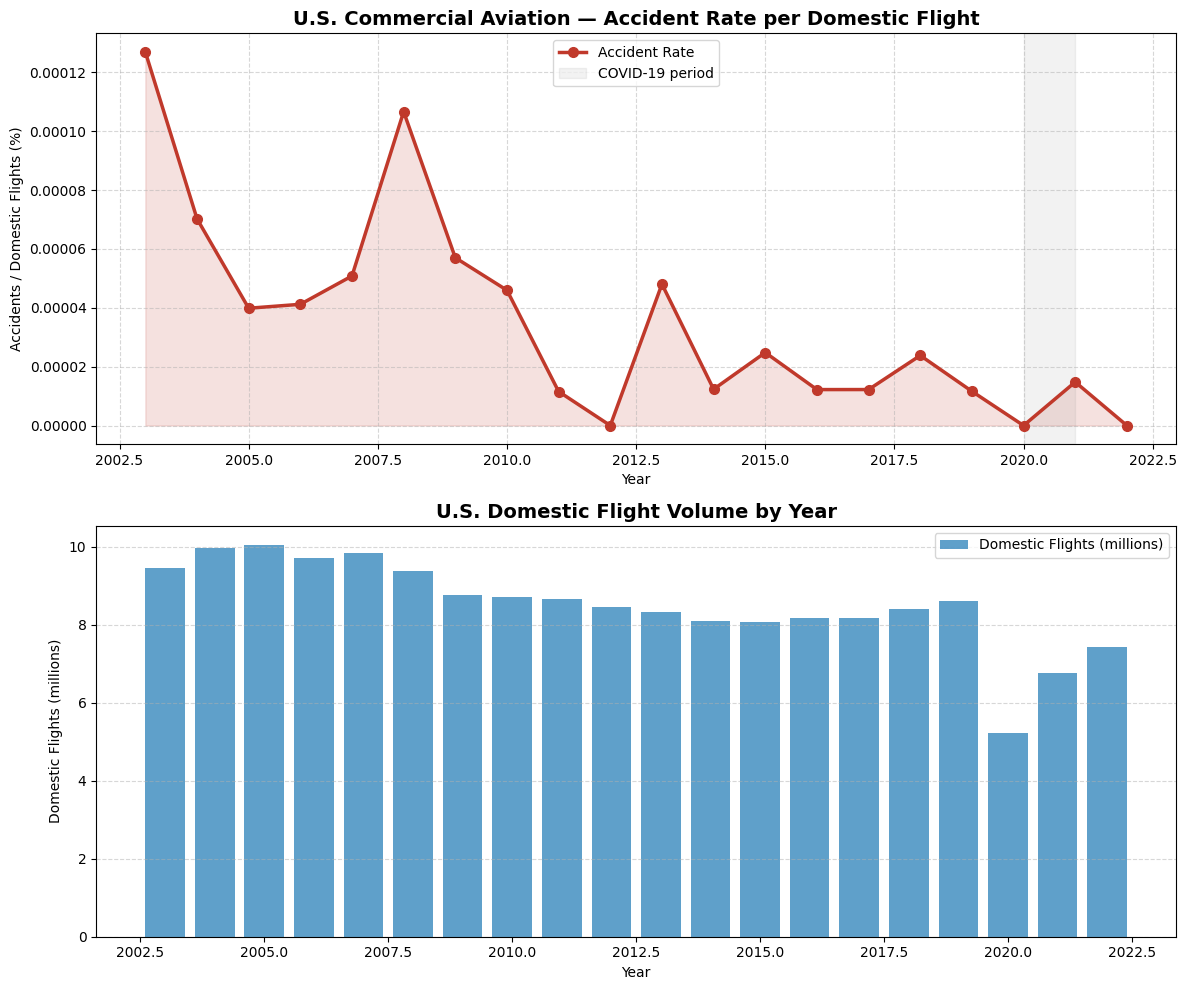

Chart saved as aviation_accident_rate.png


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# --- Plot 1: Accident Rate ---
ax1 = axes[0]
ax1.plot(traffic_df['Year'], traffic_df['Accident Rate (%)'],
         color='#C0392B', linewidth=2.5, marker='o', markersize=7, label='Accident Rate')
ax1.fill_between(traffic_df['Year'], traffic_df['Accident Rate (%)'],
                 alpha=0.15, color='#C0392B')

# COVID annotation
ax1.axvspan(2020, 2021, alpha=0.1, color='gray', label='COVID-19 period')

ax1.set_title('U.S. Commercial Aviation — Accident Rate per Domestic Flight', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Accidents / Domestic Flights (%)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# --- Plot 2: Flight Volume ---
ax2 = axes[1]
ax2.bar(traffic_df['Year'], traffic_df['Domestic Flights'] / 1e6,
        color='#2980B9', alpha=0.75, label='Domestic Flights (millions)')
ax2.set_title('U.S. Domestic Flight Volume by Year', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Domestic Flights (millions)')
ax2.legend()
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('aviation_accident_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as aviation_accident_rate.png")

### => Conclusions:
- The accident rate in 2003 was approximately **0.000127%** per domestic flight (~1 accident per 788,000 flights).
- By 2011–2022, the rate had fallen to **0.000012% or less** — an order-of-magnitude improvement.
- The COVID-19 period (2020–2021) shows near-zero rates, partly because flight volume collapsed and partly because the already-improving safety trend continued.
- The rate and volume charts above confirm this trend visually — the red line falls steeply from 2003 toward zero, while flight volume (blue bars) remains largely stable, isolating safety improvement as the driver.

# 6. Conclusions

### Key Finding
The accident rate for U.S. commercial aviation fell significantly between 2003 and 2022. The absolute number of accidents has declined from 12 in 2003 to near-zero in recent years, even as total domestic flight volume remained above 8 million per year (pre-COVID).

### Why Is Aviation Getting Safer?
The decline in accident rates is consistent with improvements across five dimensions:

| Factor | Example Developments |
|--------|---------------------|
| Aircraft technology | TAWS (Terrain Awareness and Warning Systems), enhanced autopilot, redundant systems |
| Operational procedures | Crew Resource Management (CRM), standardized checklists, stabilized approach requirements |
| Data analytics | FOQA (Flight Operations Quality Assurance), ADS-B real-time telemetry, AI anomaly detection |
| Crew training | High-fidelity simulators enabling rare-failure scenario training |
| Regulation | Ongoing safety standard updates from FAA, EASA, and ICAO |

### Limitations
- **U.S. scope only:** The accident filter uses state name matching, which may miss some U.S. accidents and may not capture accidents in U.S. territories.
- **Operator filter is approximate:** Keyword matching on `Operator` may allow some non-commercial operations to pass through.
- **No severity metric:** This analysis counts accidents, not fatalities. A fatalities-per-passenger-mile metric would give a fuller picture.
- **Small numbers in recent years:** With 1–2 accidents per year post-2013, the rate is heavily influenced by single events.

### Answers to the Research Questions

1. **Is commercial aviation in the U.S. safer today than it was two decades ago?**  
   Yes. The accident rate fell from approximately 0.00013% per domestic flight in 2003 to effectively 0 in 2020–2022 — a reduction of over 90% across two decades, while flight volume remained largely stable.

2. **What does the trend suggest about future safety?**  
   The trend points toward continued improvement. Technology, data-driven safety management (FOQA, ADS-B), and increasingly stringent regulation are compounding effects. However, emerging risk vectors — autonomous systems, urban air mobility (eVTOL), and cyber threats to avionics — introduce new unknowns that current accident data does not yet capture.

### 6.1 Export for Power BI

- The final merged dataset is exported in both CSV and Excel formats for dashboard development in Power BI.

In [20]:
# Export final dataset for Power BI integration
output_dir = "/kaggle/working" if is_kaggle else "/content"

OUTPUT_CSV   = 'aviation_data.csv'
OUTPUT_EXCEL = 'aviation_data.xlsx'

traffic_df.to_csv(OUTPUT_CSV, index=False)
traffic_df.to_excel(OUTPUT_EXCEL, index=False)

print(f"Exported: {OUTPUT_CSV}")
print(f"Exported: {OUTPUT_EXCEL}")
print(f"\nColumns in export: {list(traffic_df.columns)}")
print(f"Rows: {len(traffic_df)}")

Exported: aviation_data.csv
Exported: aviation_data.xlsx

Columns in export: ['Year', 'Domestic Passengers', 'International Passengers', 'Total Passengers', 'Domestic Flights', 'International Flights', 'Total Flights', 'Accidents', 'Accident Rate (%)']
Rows: 20


### => Conclusions:
- Two export files generated: `aviation_data.csv` and `aviation_data.xlsx`, both containing **20 annual rows** (2003–2022) with flight volume, accident counts, and computed accident rates.
- These files are ready for direct import into **Power BI** for dashboard development.

---

## Final Note

This notebook demonstrates that U.S. commercial aviation has become dramatically safer over the past two decades. The accident rate per domestic flight declined by over 90% between 2003 and 2022, even as flight volumes remained at historically high levels.

The analysis is intentionally scoped and simplified — it uses publicly available data, relies on keyword-based filtering, and counts accidents rather than fatalities. These are appropriate constraints for an exploratory project. Extensions could include fatality-weighted metrics, international scope, or time-series forecasting of future accident rates.